# **'Assignment 1: Advanced Regression and Multivariate Diagnostics' - Statistics for Data Science II**

**Inteligencia Artificial Avanzada para la Ciencia de Datos II**

TC3007C.500

**Autores**:


*   Carlo Crivelli Hernandez       - A01656171
*   Arely Yael Villatoro Amador    - A01663303
*   Ariel Lopez Garcia             - A01275913
*   Wilfrido Tovar Andrade         - A01664769
*   Ian Gabriel Rivera Reyes       - A01658613
*   Guillermo Ian Barbosa Martínez - A01747926

**Profesor**: Jesús Manuel Vázquez Nicolás

Grupo 500

**Fecha de Entrega**: 8 de octubre de 2025

## **Introducción y Objetivos**

Esta actividad tiene como propósito aplicar técnicas de regresión estadística para analizar los factores que influyen en los costos (**charges**) de seguros médicos a partir del conjunto de datos **insurance.csv**. A través de la construcción de modelos lineales, polinómicos y no lineales, se busca evaluar el ajuste, verificar las suposiciones clásicas de regresión y explorar las relaciones multivariadas entre las variables. Los objetivos son: identificar el modelo con mejor desempeño predictivo, diagnosticar posibles violaciones a los supuestos estadísticos y analizar la influencia de observaciones atípicas o correlaciones internas en la validez y confiabilidad del modelo final.

# **Librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

# **Datos**

In [2]:
df = pd.read_csv('/Users/wil/Documents/TEC/AdvancedAI_Python-Stats/Parte_2/Assignment1/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

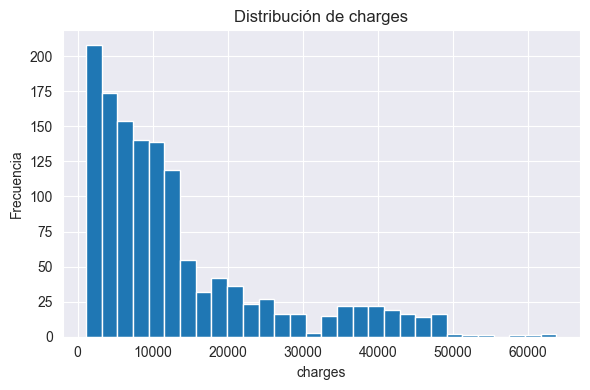

In [6]:
# Distribución de la variable objetivo: charges
plt.figure(figsize=(6,4))
plt.hist(df['charges'], bins=30)
plt.title('Distribución de charges')
plt.xlabel('charges')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# **Pre-procesamiento**

In [7]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['sex', 'region'])

for col in df.columns:
  if df[col].dtype == 'bool':
    df[col] = df[col].astype(int)

In [8]:
# Extract the features and target (charges)
X = df.drop(['charges'], axis=1)
y = df['charges']

In [29]:
df

,age,bmi,children,smoker,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,16884.92400,1,0,0,0,0,1
1,18,33.770,1,0,1725.55230,0,1,0,0,1,0
2,28,33.000,3,0,4449.46200,0,1,0,0,1,0
3,33,22.705,0,0,21984.47061,0,1,0,1,0,0
4,32,28.880,0,0,3866.85520,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830,0,1,0,1,0,0
1334,18,31.920,0,0,2205.98080,1,0,1,0,0,0
1335,18,36.850,0,0,1629.83350,1,0,0,0,1,0
1336,21,25.800,0,0,2007.94500,1,0,0,0,0,1


In [9]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

El pre-procesamiento (mapeo de **smoker** a 0/1, **one-hot encoding** de **sex** y **region**, conversión de booleanos a enteros, y **train/test split**) es necesaria para convertir las variables categóricas a formato numérico interpretable por los regresores y para evaluar generalización fuera de la muestra. A continuación, se implementarán tres distintos modelos de regresión para tratar de predecir el valor de la variable **charges** de la mejor forma.

# **Modelos de Regresión**

Para el modelo de regresión polinomial se escalan antes las características polinómicas porque el método de **Polynomial Features** de **scikit-learn** puede crear columnas con magnitudes muy distintas (lo que permite estabilizar la optimización). La elección de tres familias de modelos es por razones pedagógicas y prácticas:
* **Regresión lineal**: Como **baseline** e interpretabilidad.
* **Polinómica (grado 2)**: Para captar curvaturas e interacciones (ej: cómo $BMI \times edad$ ó $smoker \times edad$ afectan costos)
* **Exponencial (log-target)**: Para probar una relación multiplicativa/heterocedástica y mitigar el sesgo en **charges** usando retransformación con **Duan smearing**, que se aplica tras ajustar el modelo exponencial para compensar el sesgo que surge al volver de la escala logarítmica a la original, garantizando predicciones insesgadas de los costos esperados.

## **Regresión Lineal**

In [10]:
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

## **Regresión Polinomial**

In [11]:
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
     ('poly', PolynomialFeatures(degree=2, include_bias=False)),
      ('lin', LinearRegression())
])
poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

## **Regresión Exponencial**

In [12]:
# Fit del log(y) + corrección Duan smearing tras la transformación
y_train_log = np.log(y_train)
exp_model = Pipeline([
    ('scaler', StandardScaler()),
     ('lin', LinearRegression())
])
exp_model.fit(X_train, y_train_log)

# preds (log)
y_pred_log = exp_model.predict(X_test)

# factor Duan smearing de residuals (solo en la data de entrenamiento)
resid_train_log = y_train_log - exp_model.predict(X_train)
smear_factor = np.mean(np.exp(resid_train_log))

# transformación y corrección
y_pred_exp = np.exp(y_pred_log) * smear_factor

# **Evaluación de los Modelos**

In [13]:
# Métricas (evaluadas sobre escala original)
models_metrics = []
for name, y_pred in [('Linear', y_pred_lin), ('Polynomial d=2', y_pred_poly), ('Exponential (log-target)', y_pred_exp)]:
  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)
  models_metrics.append({'model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

metrics_df = pd.DataFrame(models_metrics)
print('\n--- Métricas de los modelos (test set) ---')
metrics_df


--- Métricas de los modelos (test set) ---


,model,R2,RMSE,MAE
0,Linear,0.783593,5796.284659,4181.194474
1,Polynomial d=2,0.866583,4551.132385,2729.500134
2,Exponential (log-target),0.468686,9082.168381,4756.269483


Comparando métricas, el modelo polinómico es el preferido: $R^2=0.87$, $RMSE\approx4,551$, $MAE\approx2,729$, claramente mejor que la lineal ($R^2=0.78$) y que la exponencial ($R^2=0.47$, $RMSE$ mayor). Esto sugiere que las no linealidades e interacciones de segundo orden explican mucha varianza en **charges**. Sin embargo, las polinomiales elevan riesgo de multicolinealidad y sobreajuste, por lo que se debe revisar el factor de inflación de la varianza (VIF) / diagnósticos, o bien seleccionar interacciones específicas antes de declarar el modelo final.

# **Análisis de supuestos (para el lineal)**

In [14]:
# Análisis de supuestos para el modelo Lineal (usamos statsmodels para facilidad)
X_train_sm = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_sm).fit()
print('\n--- Resumen OLS (train) ---')
print(ols.summary())


--- Resumen OLS (train) ---
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          1.32e-305
Time:                        18:33:00   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const      

In [15]:
# Residuales y fitted
fitted = ols.fittedvalues
resid = ols.resid

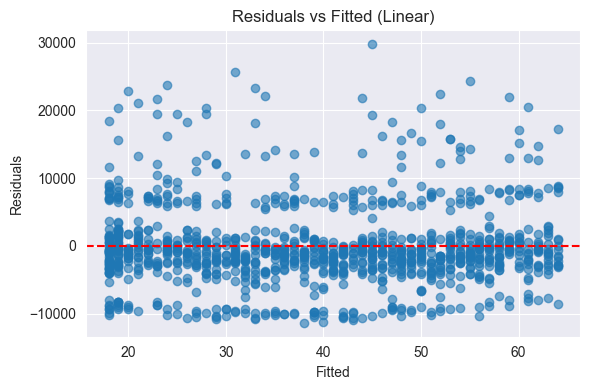

In [16]:
# Linearity: Residual vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(X_train['age'], resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Linear)')
plt.tight_layout()
plt.show()

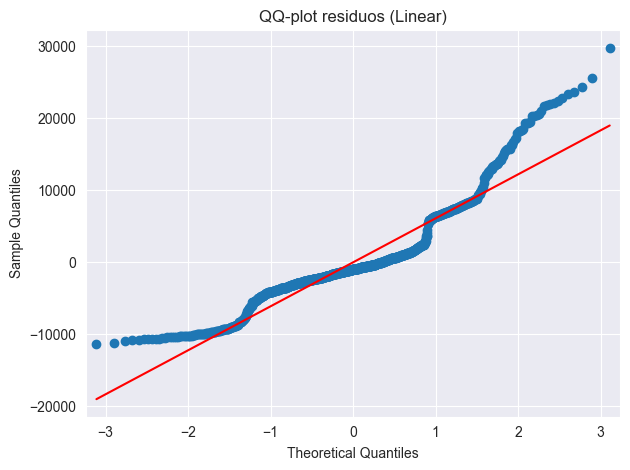

Shapiro-Wilk: estadístico=0.8944, p-valor=0.0000


In [17]:
# Normality: QQ-plot y Shapiro-Wilk
sm.qqplot(resid, line='s')
plt.title('QQ-plot residuos (Linear)')
plt.tight_layout()
plt.show()
shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")

In [18]:
# Homoscedasticity: Breusch-Pagan
bp_test = het_breuschpagan(resid, ols.model.exog)
bp_labels = ['Lagrange multiplier stat', 'p-value', 'f-value', 'f p-value']
print('\nBreusch-Pagan test:')
for lab, val in zip(bp_labels, bp_test):
  print(lab, val)


Breusch-Pagan test:
Lagrange multiplier stat 93.34462547583777
p-value 1.160121746255818e-15
f-value 12.67574138908986
f p-value 1.653865974773738e-17


In [19]:
# Independence: Durbin-Watson
dw = durbin_watson(resid)
print(f"\nDurbin-Watson: {dw:.4f} (valores cercanos a 2 indican ausencia de autocorrelación)")


Durbin-Watson: 2.0854 (valores cercanos a 2 indican ausencia de autocorrelación)


Retomando el modelo lineal, los residuos muestran una clara curvatura y dispersión variable respecto a los valores ajustados, lo que viola la suposición de linealidad y homocedasticidad (**Breusch-Pagan** $p < 0.001$). Además, en el QQ-plot, así como la prueba de **Shapiro-Wilk** ($p < 0.001$) indican que los errores no siguen una distribución normal, con cola derecha marcada por algunos valores extremos. Sin embargo, la prueba de **Durbin-Watson** $\approx2.08$ sugiere independencia entre los residuos, por lo que no hay evidencia de autocorrelación.

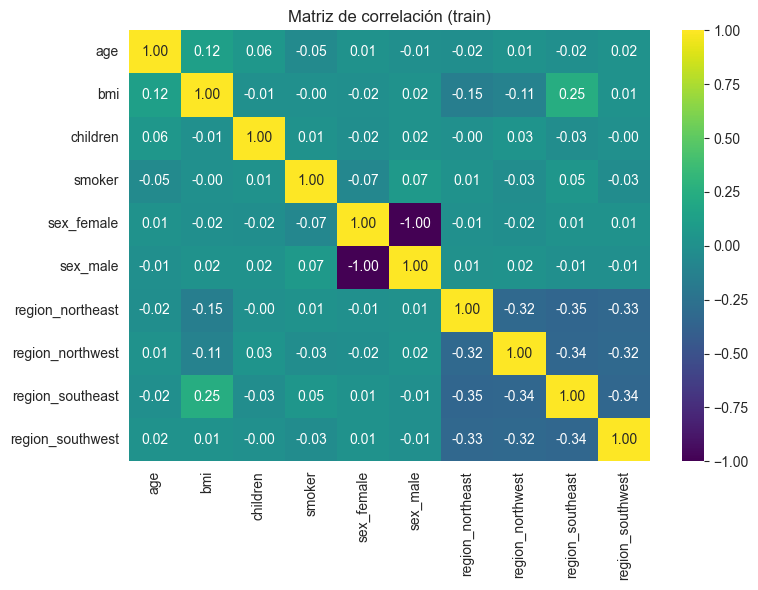

In [20]:
# Multicollinearity: Correlation matrix y VIF
corr = X_train.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis')
plt.title('Matriz de correlación (train)')
plt.tight_layout()
plt.show()

In [21]:
# VIF (añadir constantes cuando se calcule VIF no se recomienda incluir la const)
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.drop(['sex_female', 'sex_male',
                                    'region_southeast', 'region_southwest',
                                    'region_northwest', 'region_northeast'],axis=1).columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1]-6)]
print('\n--- VIF ---')
print(vif_data.sort_values('VIF', ascending=False))


--- VIF ---
    feature       VIF
1       bmi  1.094986
0       age  1.023084
3    smoker  1.011703
2  children  1.005643


Respecto a la multicolinealidad, todos los VIF < 2 y la matriz de correlación sin relaciones fuertes ($< 0.35$) confirman que no es un problema relevante, aunque la nota del resumen OLS advierte posibles redundancias debidas a las variables dummy perfectamente colineales (por eso se eliminan algunas para evitar singularidad). En conjunto, las violaciones principales —no linealidad, heterocedasticidad y no normalidad— justifican aplicar transformaciones del objetivo (por ejemplo, $log(charges)$) o usar un modelo polinómico o regularizado (con **Ridge/Lasso**), que capturen curvaturas y mitiguen la influencia de valores extremos, mejorando la validez estadística y la capacidad predictiva.

# **Análisis Multivariado**

In [22]:
# Covarianza
cov = X_train.cov()
print('\n--- Covariance (primeras filas) ---')
cov


--- Covariance (primeras filas) ---


,age,bmi,children,smoker,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
age,198.076354,10.059685,1.043914,-0.296110,0.059533,-0.059533,-0.120039,0.078209,-0.093577,0.135406
bmi,10.059685,36.522510,-0.037040,-0.008431,-0.046218,0.046218,-0.395623,-0.290619,0.659530,0.026712
children,1.043914,-0.037040,1.478616,0.006880,-0.010386,0.010386,-0.002522,0.017293,-0.013485,-0.001285
smoker,-0.296110,-0.008431,0.006880,0.163486,-0.014338,0.014338,0.001967,-0.005272,0.009180,-0.005875
sex_female,0.059533,-0.046218,-0.010386,-0.014338,0.250086,-0.250086,-0.001175,-0.003639,0.001813,0.003000
sex_male,-0.059533,0.046218,0.010386,0.014338,-0.250086,0.250086,0.001175,0.003639,-0.001813,-0.003000
region_northeast,-0.120039,-0.395623,-0.002522,0.001967,-0.001175,0.001175,0.187441,-0.059757,-0.066060,-0.061625
region_northwest,0.078209,-0.290619,0.017293,-0.005272,-0.003639,0.003639,-0.059757,0.182181,-0.063338,-0.059086
region_southeast,-0.093577,0.659530,-0.013485,0.009180,0.001813,-0.001813,-0.066060,-0.063338,0.194715,-0.065317
region_southwest,0.135406,0.026712,-0.001285,-0.005875,0.003000,-0.003000,-0.061625,-0.059086,-0.065317,0.186028


En el análisis de covarianza y correlación no se observan relaciones fuertes entre las variables independientes (todas las correlaciones se mantienen por debajo de +/- 0.35), lo que indica una baja multicolinealidad. Esto se confirma con los valores de VIF menores a 2 (y el la prueba DB cercana a dicho valor con 2.08), lo que sugiere que las variables explicativas aportan información relativamente independiente entre sí y no generan redundancia significativa en la estimación de los coeficientes. Por ello, el modelo lineal conserva estabilidad numérica y permite una interpretación confiable de los pesos asociados a cada predictor.

In [23]:
# Hat matrix y Cook's distance
influence = ols.get_influence()
leverage = influence.hat_matrix_diag
cooks, pvals = influence.cooks_distance

In [24]:
n = X_train.shape[0]
p = X_train.shape[1]
lev_threshold = 2 * (p+1) / n
cooks_threshold = 4 / n

In [25]:
# indices de puntos con leverage y cooks altos
high_lev_idx = np.where(leverage > lev_threshold)[0]
high_cooks_idx = np.where(cooks > cooks_threshold)[0]

In [26]:
print(f"\nNúmero de observaciones (train) n={n}, variables p={p}")
print(f"Umbral leverage > {lev_threshold:.5f}. observaciones con leverage alto: {len(high_lev_idx)}")
print(f"Umbral Cook's > {cooks_threshold:.5f}. observaciones con Cook's alto: {len(high_cooks_idx)}")


Número de observaciones (train) n=1070, variables p=10
Umbral leverage > 0.02056. observaciones con leverage alto: 1
Umbral Cook's > 0.00374. observaciones con Cook's alto: 48


In [27]:
# Mostrar top 10 observaciones por Cook's
cooks_series = pd.Series(cooks, index=X_train.index)
print('\nTop 10 observaciones por Cook\'s distance:')
print(cooks_series.sort_values(ascending=False).head(10))


Top 10 observaciones por Cook's distance:
1300    0.019379
577     0.018630
819     0.015298
1230    0.014500
1012    0.012725
219     0.012041
1027    0.011501
34      0.010242
321     0.009523
242     0.009379
dtype: float64


In [28]:
# Recomendaciones automáticas
print('\n--- Recomendaciones basadas en diagnósticos ---')
if shapiro_p < 0.05:
  print('- Residuales no normales: considerar transformar la variable objetivo (log, sqrt) o usar regresión robusta.')
else:
  print('- Residuales aparentan normales según Shapiro-Wilk.')


if bp_test[1] < 0.05:
  print('- Heteroscedasticidad detectada: considerar WLS, transformar y/o usar errores robustos (HC).')
else:
  print('- No se detectó heteroscedasticidad significativa.')


if any(vif_data['VIF'] > 5):
  print('- Multicolinealidad presente (VIF > 5): considerar eliminar variables, combinar variables, o usar regularización (Ridge/Lasso).')
else:
  print('- No se observan VIF altos (multicolinealidad baja).')


if len(high_cooks_idx) > 0 or len(high_lev_idx) > 0:
  print('- Existen observaciones influyentes/alto leverage: revisar y decidir si remover, transformar o usar métodos robustos.')
else:
  print('- No se detectaron observaciones altamente influyentes según umbrales usados.')


--- Recomendaciones basadas en diagnósticos ---
- Residuales no normales: considerar transformar la variable objetivo (log, sqrt) o usar regresión robusta.
- Heteroscedasticidad detectada: considerar WLS, transformar y/o usar errores robustos (HC).
- No se observan VIF altos (multicolinealidad baja).
- Existen observaciones influyentes/alto leverage: revisar y decidir si remover, transformar o usar métodos robustos.


A su vez, el diagnóstico de influencia revela una observación con **leverage** alto y 48 con valores elevados de la distancia de Cook, lo que señala la presencia de puntos con gran influencia en el ajuste global del modelo. Estos valores extremos podrían distorsionar los coeficientes estimados y las métricas de error, reduciendo la robustez y generalización del modelo. En este caso, sería recomendable revisar dichas observaciones, evaluar si corresponden a errores o casos atípicos genuinos, y considerar técnicas como las transformaciones enlistadas en la celda anterior que reduzcan su impacto sobre la confiabilidad del modelo.

# **Conclusión**
En conclusión, el modelo polinómico de grado 2 resultó ser el más adecuado al obtener el mayor $R^2$ (0.87) y los menores errores (**RMSE** y **MAE**), demostrando una mejor capacidad para capturar las relaciones no lineales entre las variables y los costos de seguro (**charges**). No obstante, en el modelo lineal (más simple) se observaron violaciones a las suposiciones de linealidad, normalidad y homocedasticidad, lo que reduce la confiabilidad de sus inferencias y justifica el uso de transformaciones o modelos más flexibles. De igual forma, el análisis multivariado mostró baja multicolinealidad, pero la existencia de algunos puntos influyentes podría afectar ligeramente la estabilidad de los coeficientes; por ello, la interpretación final del modelo debe considerar que el comportamiento de los costos médicos está influido por relaciones complejas y no estrictamente lineales entre las variables predictoras.